## Introduction on how to use the simulation

In [1]:
# Imports and loading of NEURON dll
import numpy as np
from neuron import h
import simulation as sim
import matplotlib.pyplot as plt
import helperFuncs as hf

## Example of running a full simulated electrical stimulation experiment

### Setting up the simulated cell

In [2]:
# clear all NEURON sims. Required if you are going to be running many exps
#  in Jupyter notebooks.
for sec in h.allsec():
   h.delete_section(sec=sec)

In [3]:
# Code to setup a single simulated RGC
RGC = sim.Local_Cell()
filename = 'cell_param_files/params_35.csv'
RGC.build_cell(filename, 'mammalian_spike_35')

After any change to cell geometry or nseg, be sure to invoke setpointers()


In [4]:
# print out where the center of the soma is located and shift if needed
#  Note, behind the scenes this is shifting all simualted compartments by 
#  the necessary x,y,z transforms to get the cell to the right spot 
print('Current soma center is located at: ', RGC.soma_center)
# RGC.shift_cell_x_y_z(0,0,0)
# print('New soma center is located at: ', RGC.soma_center)

Current soma center is located at:  [-11.9399995803833, 0.0, 10.0]


### Setting up the multielectrode electrical stimulus 

In [21]:
### Most features of the stimulus are set up a struct (dict) called Stim 
Stim = {}

# temporal features of the sitmulus 
Stim['pulseShape'] = 'biphasic'
Stim['dt'] = .005 # units: [ms]
Stim['delay'] = 10 # units: [ms]
Stim['dur'] = 0.05 # units: [ms]
Stim['stop'] = 80 # units: [ms]
Stim['amp'] = [-6.19] # units: [uA]

# calibration phase of the stimulus 
Stim['initDur'] = 50 # units: [ms]
Stim['initDt'] = 1 # units: [ms]
Stim['vInit'] = -70 # units: [mV] #TODO: Old is -70

# spatial features of the stimulus 
# --> specifically defining the electrode geometry 
Stim['electrodes'] = [[-1000,0,30]] 
Stim['electrode_type'] = 'point'
Stim['rhoExt'] = 1000 # Ohm*cm
Stim['elecDiam'] = 15 # um 15
Stim['polarity'] = -1 # anodic == 1; cathodic == -1 

Stim['pulseRatioTri'] = [-2/3,1,-1/3]
Stim['pulseRatioBi'] = [1,-1]
Stim['frequency'] = 10 # units: [Hz]

### Run threshold finding code

In [23]:
# Here, vRec is the voltage along the axon
thr_c, t_vec, vRec_cathodic = hf.lowerThreshold_v2(Stim, RGC, lower=0, upper=5, num=20, epsilon=0.02) # num=25
# thr_c, t_vec, vRec_cathodic = hf.lowerThreshold_v2(Stim, RGC, lower=0, upper=4, num=35, epsilon=0.02)

Starting trial with 2.2864231539301976 upper bound = 2.585328384551423 lower bound = 1.9875179233089715
Starting trial with 2.4358757692408104 upper bound = 2.585328384551423 lower bound = 2.2864231539301976
Starting trial with 2.5106020768961166 upper bound = 2.585328384551423 lower bound = 2.4358757692408104
Starting trial with 2.4732389230684637 upper bound = 2.5106020768961166 lower bound = 2.4358757692408104
Starting trial with 2.454557346154637 upper bound = 2.4732389230684637 lower bound = 2.4358757692408104
Lower threshold found at:  2.454557346154637  uA


## Run just a single trial

In [17]:
### Most features of the stimulus are set up a struct (dict) called Stim 
Stim = {}

# temporal features of the sitmulus 
Stim['pulseShape'] = 'biphasic'
Stim['dt'] = .005 # units: [ms]
Stim['delay'] = 10 # units: [ms]
Stim['dur'] = 0.05 # units: [ms]
Stim['stop'] = 80 # units: [ms]
Stim['amp'] = [-1] # units: [uA]

# calibration phase of the stimulus 
Stim['initDur'] = 50 # units: [ms]
Stim['initDt'] = 1 # units: [ms]
Stim['vInit'] = -70 # units: [mV] #TODO: Old is -70

# spatial features of the stimulus 
# --> specifically defining the electrode geometry 
Stim['electrodes'] = [[-1000,0,30]] 
Stim['electrode_type'] = 'point'
Stim['rhoExt'] = 1000 # Ohm*cm
Stim['elecDiam'] = 15 # um 15
Stim['polarity'] = -1 # anodic == 1; cathodic == -1 

Stim['pulseRatioTri'] = [-2/3,1,-1/3]
Stim['pulseRatioBi'] = [1,-1]
Stim['frequency'] = 10 # units: [Hz]

# have to set transfer impedances ANY TIME stimulus parameters are changed!! 
# Stim['electrodes'] = [[-1000,0,49]] # electrode location
hf.setupTransferImpedance_v2(Stim, RGC)

In [18]:
# Run single trial
# Play the stimulus into the cell, setting it up for stimulation
tsvec, isvec = hf.setupStimulus_unit(Stim)
isvec.play(h._ref_is_xtra, tsvec, 1) 

# set up recording vectors at every axonal segment 
vRec = []
for seg in RGC.axon:
    vRec.append(h.Vector().record(RGC.axon(seg.x)._ref_v))

# set up recoring vector for time in the simulation 
t_vec = h.Vector().record(h._ref_t)

# Initialization phase of the simulation 
h.init()
h.tstop = Stim['initDur']
h.dt = Stim['initDt']
h.finitialize(Stim['vInit'])
h.continuerun(h.tstop)

# Run the simulation 
h.tstop = Stim['initDur'] + Stim['stop']
h.steps_per_ms = int(1/Stim['dt'])
h.dt = Stim['dt']
h.continuerun(h.tstop)
print('***** sim done *****')

***** sim done *****


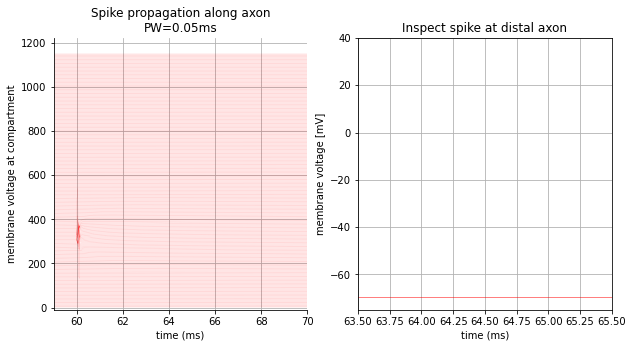

In [19]:
# Example of plotting voltage traces at all axonal segments, tracking spike
#  propagation along the membrane, expanding across space
fig, (ax,ax2) = plt.subplots(1,2,figsize=(10,5))
ax.grid()
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)

offset = -1*-70
offset_step = 2
for i in range(576):
    ax.plot(t_vec,vRec[i]+offset,'r',linewidth=0.1, alpha=0.5)

    offset += offset_step

dur = Stim['dur']
ax.set_title(f'Spike propagation along axon\nPW={dur}ms')
ax.set_xlabel('time (ms)')
ax.set_ylabel('membrane voltage at compartment')

ax.set_xlim(59,70)
ax.set_ylim(-10,int(576)*offset_step+70)

## Now, plot the spike just at the distal axon, noting timing difference
ax2.plot(t_vec,vRec[-1],'r',linewidth=0.5)

ax2.set_title('Inspect spike at distal axon')
ax2.set_xlabel('time (ms)')
ax2.set_ylabel('membrane voltage [mV]')

ax2.grid()
ax2.set_xlim(63.5,65.5)
ax2.set_ylim(-75,40)

plt.show()

## Read out results from script

In [32]:
electrodes = []
for x in [-1000,-65,0]:
    for y in [0]:
        for z in np.arange(10,60,5):
            electrodes.append([x,y,z])

# Load in thresholds
thresholds = []
for electrode in electrodes:
    filename = '/Volumes/Scratch/Users/vilkhu/sim-data/pillar/biphasic/'+\
                str(electrode[0])+'_'+\
                str(electrode[1])+'_'+\
                str(electrode[2])+'.pkl'
    data = hf.decompress_pickle(filename)
    thresholds.append(data[0])

In [36]:
for ii,electrode in enumerate(electrodes):
    print(electrode, thresholds[ii])

[-1000, 0, 10] 9.599609718064315
[-1000, 0, 15] 7.19279950125187
[-1000, 0, 20] 5.216414260801006
[-1000, 0, 25] 3.6390883007045147
[-1000, 0, 30] 2.454557346154637
[-1000, 0, 35] 1.8785513854756442
[-1000, 0, 40] inf
[-1000, 0, 45] 1.8785513854756442
[-1000, 0, 50] 2.49192049998229
[-1000, 0, 55] 3.665994377170418
[-65, 0, 10] 2.8992057421954947
[-65, 0, 15] 2.024881077136625
[-65, 0, 20] 1.385616406419131
[-65, 0, 25] 0.9013769377277975
[-65, 0, 30] 0.512295849794872
[-65, 0, 35] 0.2151117082006441
[-65, 0, 40] 0.2151117082006441
[-65, 0, 45] 0.4942835217308437
[-65, 0, 50] 0.8581436499366508
[-65, 0, 55] 1.2688765373466007
[0, 0, 10] 1.1780788614012994
[0, 0, 15] 1.2688765373466007
[0, 0, 20] 1.4375007926735888
[0, 0, 25] 1.6917516063327973
[0, 0, 30] 2.024881077136625
[0, 0, 35] 2.398512615413157
[0, 0, 40] 2.8543661196749133
[0, 0, 45] 3.39693361251139
[0, 0, 50] 4.002320332994202
[0, 0, 55] 4.712687735968027


In [38]:
# plot planer elec (disk approx) result 
electrodes_disk = []
for x in [-1000,-65,0]:
    for y in [0]:
        for z in [57]:
            electrodes_disk.append([x,y,z])

# Load in thresholds
thresholds_disk = []
for electrode in electrodes:
    filename = '/Volumes/Scratch/Users/vilkhu/sim-data/pillar/biphasic/planer_'+\
                str(electrode[0])+'_'+\
                str(electrode[1])+'_'+\
                str(electrode[2])+'.pkl'
    data = hf.decompress_pickle(filename)
    thresholds_disk.append(data[0])

In [39]:
for ii,electrode in enumerate(electrodes_disk):
    print(electrode, thresholds_disk[ii])

[-1000, 0, 57] 2.2677415770163707
[-65, 0, 57] 0.7716770743543577
[0, 0, 57] 2.54796523072377
